# Returns Data

This notebook builds a measure of return on loans in the aggregate using FDIC Call Reports data following the formulation by Kashyap and Stein. 


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
fdic_data = pd.read_csv('../raw/fred_loan_return/fred_loan_return_aligned.csv')
fdic_data["charge_off_rate"] = fdic_data["charge_off_rate"] /100
fdic_data = fdic_data.dropna(subset=["charge_off_rate"])
fdic_data = fdic_data.set_index('DATE')
fdic_data.head()

,loan_interest_income,total_loans,net_chargeoffs,charge_off_rate
DATE,,,,
1985-01-01,58933.893,2272604.168,2193.657,0.0128
1985-04-01,60108.026,2332064.493,2901.732,0.0120
1985-07-01,60972.299,2395051.476,3323.487,0.0142
1985-10-01,61986.986,2456697.343,5004.488,0.0145
1986-01-01,61506.019,2477905.620,3045.928,0.0146


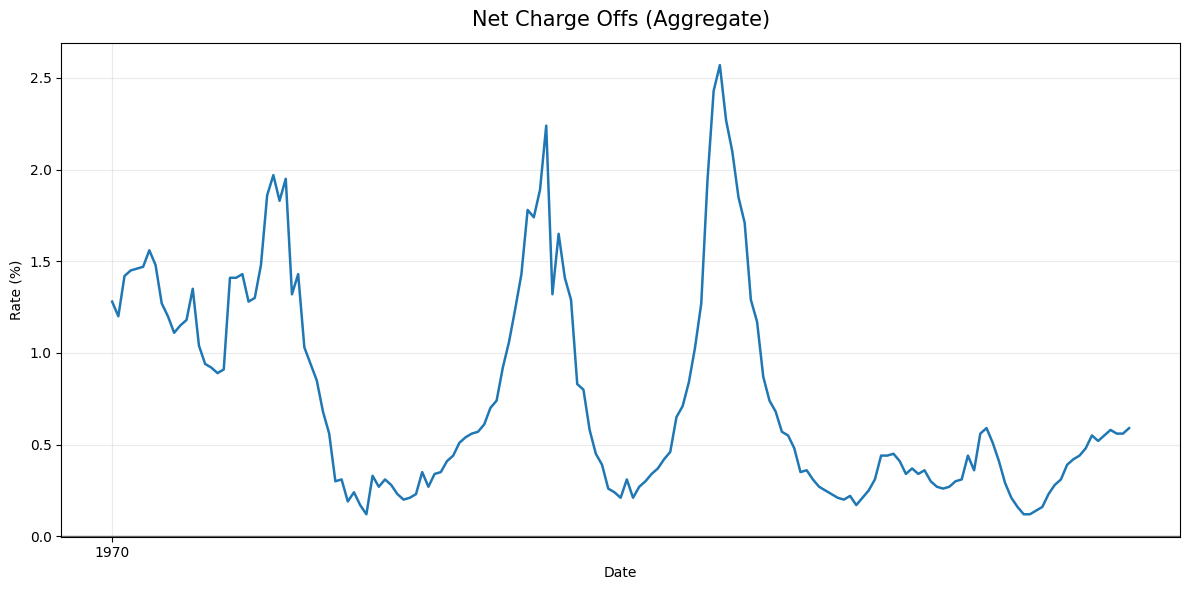

In [3]:

fig_rt, ax = plt.subplots(figsize=(12, 6))

ax.plot(fdic_data.index, fdic_data["charge_off_rate"]*100, color="#1f77b4", linewidth=1.8)
ax.axhline(0, color="#333333", linewidth=1, alpha=0.7)

ax.set_title("Net Charge Offs (Aggregate)", fontsize=15, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Rate (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  
ax.xaxis.set_major_locator(mdates.YearLocator(5))         
ax.grid(True, alpha=0.25)

fig_rt.tight_layout()
plt.show()

## NBER recession regimes for charge-offs

Download the FRED `USREC` NBER recession indicator, align it to the quarterly FDIC charge-off series, and estimate charge-off distribution parameters separately for normal and stress regimes.

In [4]:
from pathlib import Path
from urllib.parse import urlencode

# FRED's public graph CSV endpoint does not require an API key.
USREC_SERIES = "USREC"
usrec_path = '../raw/fred_loan_return/USREC.csv'

usrec = pd.read_csv(usrec_path)

usrec = usrec.rename(columns={"observation_date": "DATE", "DATE": "DATE"})
usrec["DATE"] = pd.to_datetime(usrec["DATE"])
usrec[USREC_SERIES] = pd.to_numeric(usrec[USREC_SERIES].replace(".", np.nan), errors="coerce")
usrec = usrec.dropna(subset=["DATE", USREC_SERIES]).set_index("DATE").sort_index()

usrec_monthly = usrec[USREC_SERIES].astype(int)
recession_starts = usrec_monthly[
    usrec_monthly.eq(1) & usrec_monthly.shift(fill_value=0).eq(0)
].index
recession_ends = usrec_monthly[
    usrec_monthly.eq(1) & usrec_monthly.shift(-1, fill_value=0).eq(0)
].index
nber_recession_dates = pd.DataFrame({"start": recession_starts, "end": recession_ends})

print(f"Loaded {USREC_SERIES} from {usrec_path}")
print("Recent NBER recession periods from USREC:")
display(nber_recession_dates.tail(10))

Loaded USREC from ../raw/fred_loan_return/USREC.csv
Recent NBER recession periods from USREC:


,start,end
25,1957-09-01,1958-04-01
26,1960-05-01,1961-02-01
27,1970-01-01,1970-11-01
28,1973-12-01,1975-03-01
29,1980-02-01,1980-07-01
30,1981-08-01,1982-11-01
31,1990-08-01,1991-03-01
32,2001-04-01,2001-11-01
33,2008-01-01,2009-06-01
34,2020-03-01,2020-04-01


In [5]:
# Align monthly NBER recession indicator to quarterly charge-off observations.
# max() marks a quarter as stress if any month in that quarter is in recession.
N_EXTENSION_QUARTERS = 4
charge_off_regimes = fdic_data[["net_chargeoffs", "total_loans", "charge_off_rate"]].copy()
charge_off_regimes.index = pd.to_datetime(charge_off_regimes.index)
charge_off_regimes = charge_off_regimes.dropna(subset=["charge_off_rate"]).sort_index()

usrec_quarterly = usrec[USREC_SERIES].resample("QS").max().rename("nber_recession")

usrec_extended = usrec_quarterly.copy()
for i in range(N_EXTENSION_QUARTERS):
    usrec_extended = usrec_extended | usrec_quarterly.shift(i+1, freq="QS").reindex(usrec_extended.index).fillna(0).astype(bool)
usrec_extended = usrec_extended.astype(int)

usrec_extension_only = (usrec_extended - usrec_quarterly.reindex(usrec_extended.index).fillna(0).astype(int)).clip(lower=0)


#charge_off_regimes = charge_off_regimes.join(usrec_quarterly, how="left")
charge_off_regimes = charge_off_regimes.join(usrec_extended.rename("nber_recession"), how="left")

charge_off_regimes["nber_recession"] = charge_off_regimes["nber_recession"].ffill().fillna(0).astype(int)
charge_off_regimes["regime"] = np.where(charge_off_regimes["nber_recession"].eq(1), "stress", "normal")

charge_off_regime_params = (
    charge_off_regimes
    .groupby("regime")["charge_off_rate"]
    .agg(mu="mean", sigma="std", observations="count")
    .reindex(["normal", "stress"])
)

print("Charge-off rate parameters by NBER regime")
display(charge_off_regime_params)
charge_off_regimes.tail()

Charge-off rate parameters by NBER regime


,mu,sigma,observations
regime,,,
normal,0.006056,0.004240,135
stress,0.014297,0.006737,30


,net_chargeoffs,total_loans,charge_off_rate,nber_recession,regime
DATE,,,,,
2025-01-01,21258.733,1.278703e+07,0.0055,0,normal
2025-04-01,19390.527,1.305077e+07,0.0058,0,normal
2025-07-01,20132.311,1.320973e+07,0.0056,0,normal
2025-10-01,20891.337,1.347753e+07,0.0056,0,normal
2026-01-01,NaN,NaN,0.0059,0,normal


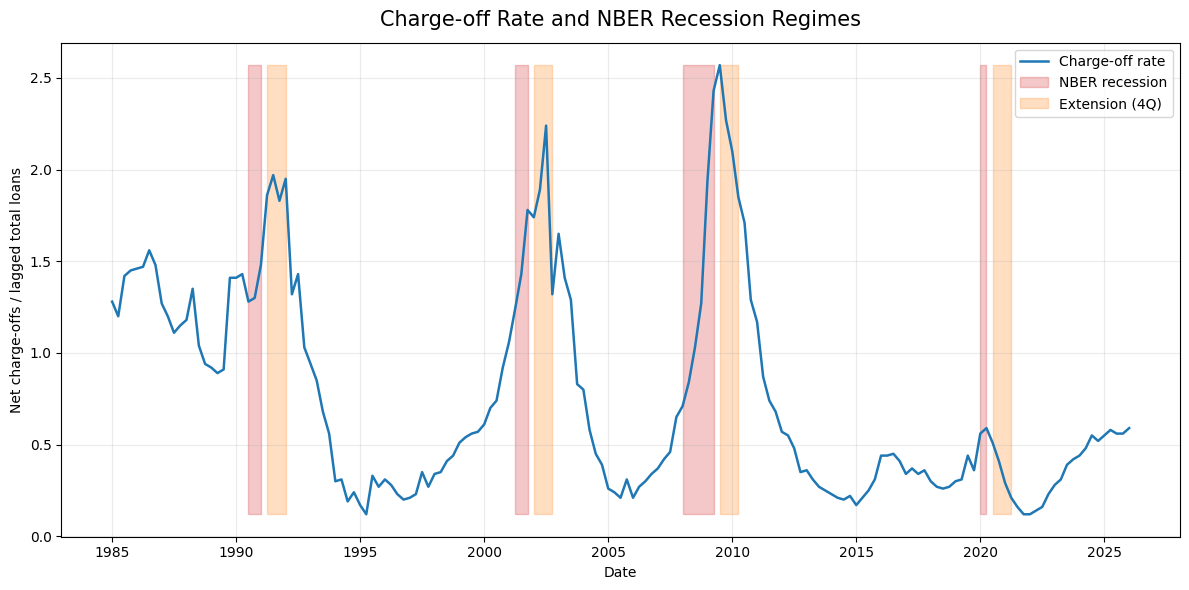

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    charge_off_regimes.index,
    charge_off_regimes["charge_off_rate"]*100,
    color="#1f77b4",
    linewidth=1.8,
    label="Charge-off rate",
)

# build both flags on the charge_off_regimes index directly
nber_original = usrec_quarterly.reindex(charge_off_regimes.index, method="ffill").fillna(0).astype(bool)
nber_full = usrec_extended.reindex(charge_off_regimes.index, method="ffill").fillna(0).astype(bool)
nber_extension_only = nber_full & ~nber_original

ax.fill_between(
    charge_off_regimes.index,
    (charge_off_regimes["charge_off_rate"]*100).min(),
    (charge_off_regimes["charge_off_rate"]*100).max(),
    where=nber_original,
    color="#d62728",
    alpha=0.25,
    step="mid",
    label="NBER recession",
)

ax.fill_between(
    charge_off_regimes.index,
    (charge_off_regimes["charge_off_rate"]*100).min(),
    (charge_off_regimes["charge_off_rate"]*100).max(),
    where=nber_extension_only,
    color="#ff7f0e",
    alpha=0.25,
    step="mid",
    label=f"Extension ({N_EXTENSION_QUARTERS}Q)",
)

ax.set_title("Charge-off Rate and NBER Recession Regimes", fontsize=15, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Net charge-offs / lagged total loans")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.grid(True, alpha=0.25)
ax.legend()

fig.tight_layout()
plt.savefig('../figures/charge_off_rate_with_NBER_recessions')
plt.show()

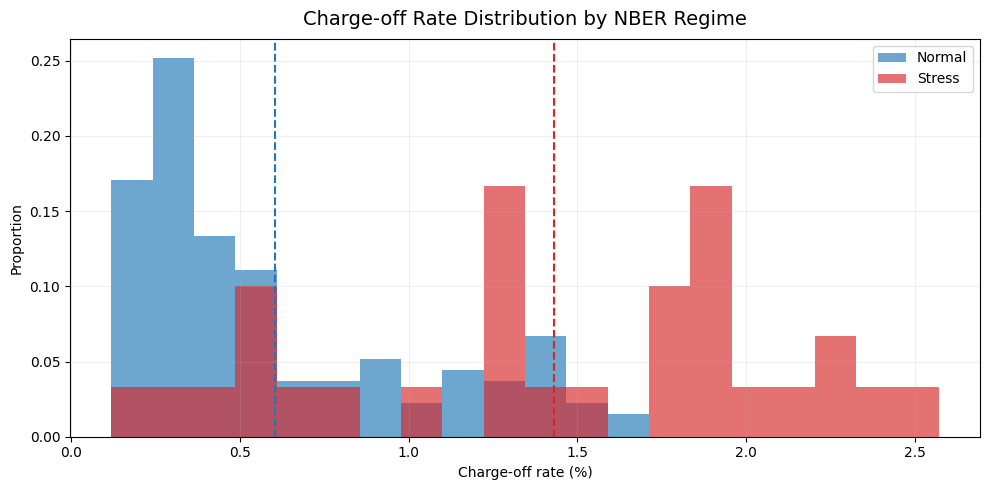

mu_normal:    0.006056
sigma_normal: 0.004240
mu_stress:    0.014297
sigma_stress: 0.006737


In [7]:
normal_charge_offs = charge_off_regimes.loc[
    charge_off_regimes["regime"].eq("normal"), "charge_off_rate"
]
stress_charge_offs = charge_off_regimes.loc[
    charge_off_regimes["regime"].eq("stress"), "charge_off_rate"
]

normal_plot = normal_charge_offs * 100
stress_plot = stress_charge_offs * 100

fig, ax = plt.subplots(figsize=(10, 5))
total_n = len(normal_charge_offs)
total_s = len(stress_charge_offs)

bins = np.linspace(
    min(normal_plot.min(), stress_plot.min()),
    max(normal_plot.max(), stress_plot.max()),
    21  # 20 bins, same edges for both
)

ax.hist(normal_plot, bins=bins, alpha=0.65, weights=[1/total_n]*total_n, label="Normal", color="#1f77b4")
ax.hist(stress_plot, bins=bins, alpha=0.65, weights=[1/total_s]*total_s, label="Stress", color="#d62728")

# multiply vlines by 100 for display only
ax.axvline(charge_off_regime_params.loc["normal", "mu"] * 100, color="#1f77b4", linestyle="--", linewidth=1.5)
ax.axvline(charge_off_regime_params.loc["stress", "mu"] * 100, color="#d62728", linestyle="--", linewidth=1.5)

ax.set_title("Charge-off Rate Distribution by NBER Regime", fontsize=14, pad=10)
ax.set_xlabel("Charge-off rate (%)")
ax.set_ylabel("Proportion")
ax.legend()
ax.grid(True, alpha=0.2)

fig.tight_layout()
plt.savefig('../figures/charge_off_rate_GMM.png')
plt.show()

# parameters stay in decimal — untouched
mu_normal = charge_off_regime_params.loc["normal", "mu"]
sigma_normal = charge_off_regime_params.loc["normal", "sigma"]
mu_stress = charge_off_regime_params.loc["stress", "mu"]
sigma_stress = charge_off_regime_params.loc["stress", "sigma"]

print(f"mu_normal:    {mu_normal:.6f}")
print(f"sigma_normal: {sigma_normal:.6f}")
print(f"mu_stress:    {mu_stress:.6f}")
print(f"sigma_stress: {sigma_stress:.6f}")

In [8]:
from scipy.stats import norm
import numpy as np

def asset_correlation(pd_hat):
    """Basel corporate IRB asset correlation R(PD)."""
    pd_hat = np.asarray(pd_hat, dtype=float)
    exponential_weight = (1 - np.exp(-50 * pd_hat)) / (1 - np.exp(-50))
    return 0.12 * exponential_weight + 0.24 * (1 - exponential_weight)


def k_irb(pd_hat, lgd=0.45):
    """IRB capital requirement K_IRB(PD) for a given LGD."""
    pd_hat = np.asarray(pd_hat, dtype=float)
    r = asset_correlation(pd_hat)
    systematic_shock = norm.ppf(0.999)
    conditional_default_argument = (
        norm.ppf(pd_hat) / np.sqrt(1 - r)
        + np.sqrt(r / (1 - r)) * systematic_shock
    )
    b = (0.11852 -0.05478*np.log(pd_hat))**2
    maturity_adjustment = 1/(1-1.5*b)
    return (lgd * norm.cdf(conditional_default_argument) - pd_hat *lgd )*maturity_adjustment

pd_normal = mu_normal / 0.45
pd_stress = mu_stress/ 0.45

print(f"PD normal:       {pd_normal:.6f}")
print(f"K_IRB normal:    {k_irb(pd_normal):.6f}")
print(f"")
print(f"PD stress:       {pd_stress:.6f}")
print(f"K_IRB stress:    {k_irb(pd_stress):.6f}")

PD normal:       0.013458
K_IRB normal:    0.081661

PD stress:       0.031770
K_IRB stress:    0.104411


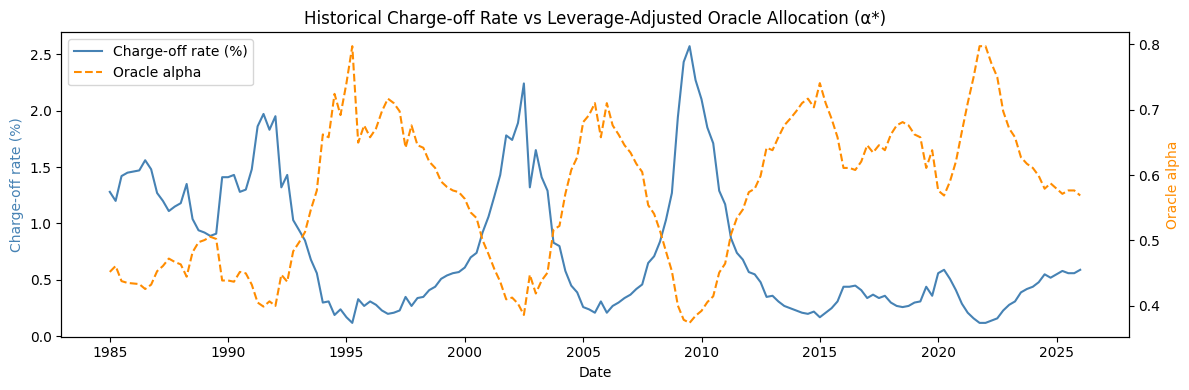

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize_scalar

import matplotlib.dates as mdates


LGD    = 0.45
Y_BAR  = 0.05
LAMBDA = 20
K1 = 1
ELL = 10


def kirb(pd):
    if pd <= 0: return 0.0
    pd = max(pd, 1e-6)
    pd = min(pd, 0.99) # prevent ppf(1.0) inf values
    
    e50 = np.exp(-50)
    f = (1 - np.exp(-50 * pd)) / (1 - e50)
    R = 0.12 * f + 0.24 * (1 - f)
    
    # Keeping your maturity adjustment setup
    b = (0.11852 - 0.05478 * np.log(pd))**2
    maturity = 2.5
    maturity_adj = (1 + (maturity - 2.5) * b) / (1 - 1.5 * b)

    arg = norm.ppf(pd) / np.sqrt(1 - R) + np.sqrt(R / (1 - R)) * norm.ppf(0.999)
    return float(LGD * (norm.cdf(arg) - pd)) * maturity_adj

def oracle_alpha(c):
    # Convert quarterly charge-off rate to an annualized PD input
    pd_q = c / LGD
    pd_a = 1.0 - (1.0 - pd_q) ** 4
    k = kirb(pd_a)
    
    alphas_test = np.linspace(0, 1, 20)
    for a in alphas_test:
        terminal = K1 + a * (Y_BAR - c)
        available_buffer = terminal - a * K1
        required = k * a
       
 

    def u(alpha):
        # Actual risky loan exposure
        exposure = ELL * alpha * K1

        # Terminal capital: initial capital plus profit/loss on the loan exposure
        terminal_capital = K1 + exposure * (Y_BAR - c)

        # Capital tied up in the risky loan book
        committed_capital = alpha * K1

        # Available buffer excludes the committed equity/capital allocation
        available_buffer = terminal_capital - committed_capital

        # IRB required capital applies to loan exposure, not just alpha*K1
        required_capital = k * exposure

        shortfall = max(required_capital - available_buffer, 0.0)

        return terminal_capital - LAMBDA * shortfall**2
            
    # Maximize utility (minimize negative utility)
    result = minimize_scalar(lambda a: -u(a), bounds=(0.0, 1.0), method="bounded")
    return float(result.x), k

# ── Your data processing step ────────────────────────────────────────────────
dates        = fdic_data.index   
charge_offs  = fdic_data.charge_off_rate.values  
dates = pd.to_datetime(fdic_data.index).tz_localize(None).to_numpy()


# ── Compute dynamic oracle choices ───────────────────────────────────────────
out = np.array([oracle_alpha(c) for c in charge_offs])
alphas = out[:, 0]
k_irb = out[:, 1]

oracle_alpha_series = pd.DataFrame({"alpha": alphas}, index=dates)
oracle_alpha_series.to_csv('../processed/oracle_alpha.csv')

# ── Plotting code remains identical ──────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(dates, charge_offs * 100, color="steelblue", label="Charge-off rate (%)")
ax1.set_ylabel("Charge-off rate (%)", color="steelblue")
ax1.set_xlabel("Date")
ax1.xaxis.set_major_locator(mdates.YearLocator(5))   # every 5 years
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax2 = ax1.twinx()
ax2.plot(dates, alphas, color="darkorange", linestyle="--", label="Oracle alpha")
ax2.set_ylabel("Oracle alpha", color="darkorange")
ax2.xaxis.set_major_locator(mdates.YearLocator(5))   # every 5 years
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.title("Historical Charge-off Rate vs Leverage-Adjusted Oracle Allocation (α*)")
plt.tight_layout()
plt.savefig("../figures/historical_charge_off_vs_alpha_leverage.png")
plt.show()

IRB regret min/max: 0.0 105.14136709144472
IRB regret 95th percentile: 24.628231892811122
IRB max diagonal regret: 0.0012111916832582281
IRB predicted alpha range: 0.4079214608238519 0.9999940391390134
IRB oracle alpha range: 0.40845800238633734 0.9999940391390134
Linear regret min/max: 7.813513026788677e-05 54.75558065940505
Linear regret 95th percentile: 19.99020618552361
Linear predicted alpha range: 0.3886147493975086 0.7957778221731596
Linear oracle alpha range: 0.38910055260215687 0.7989405495781546


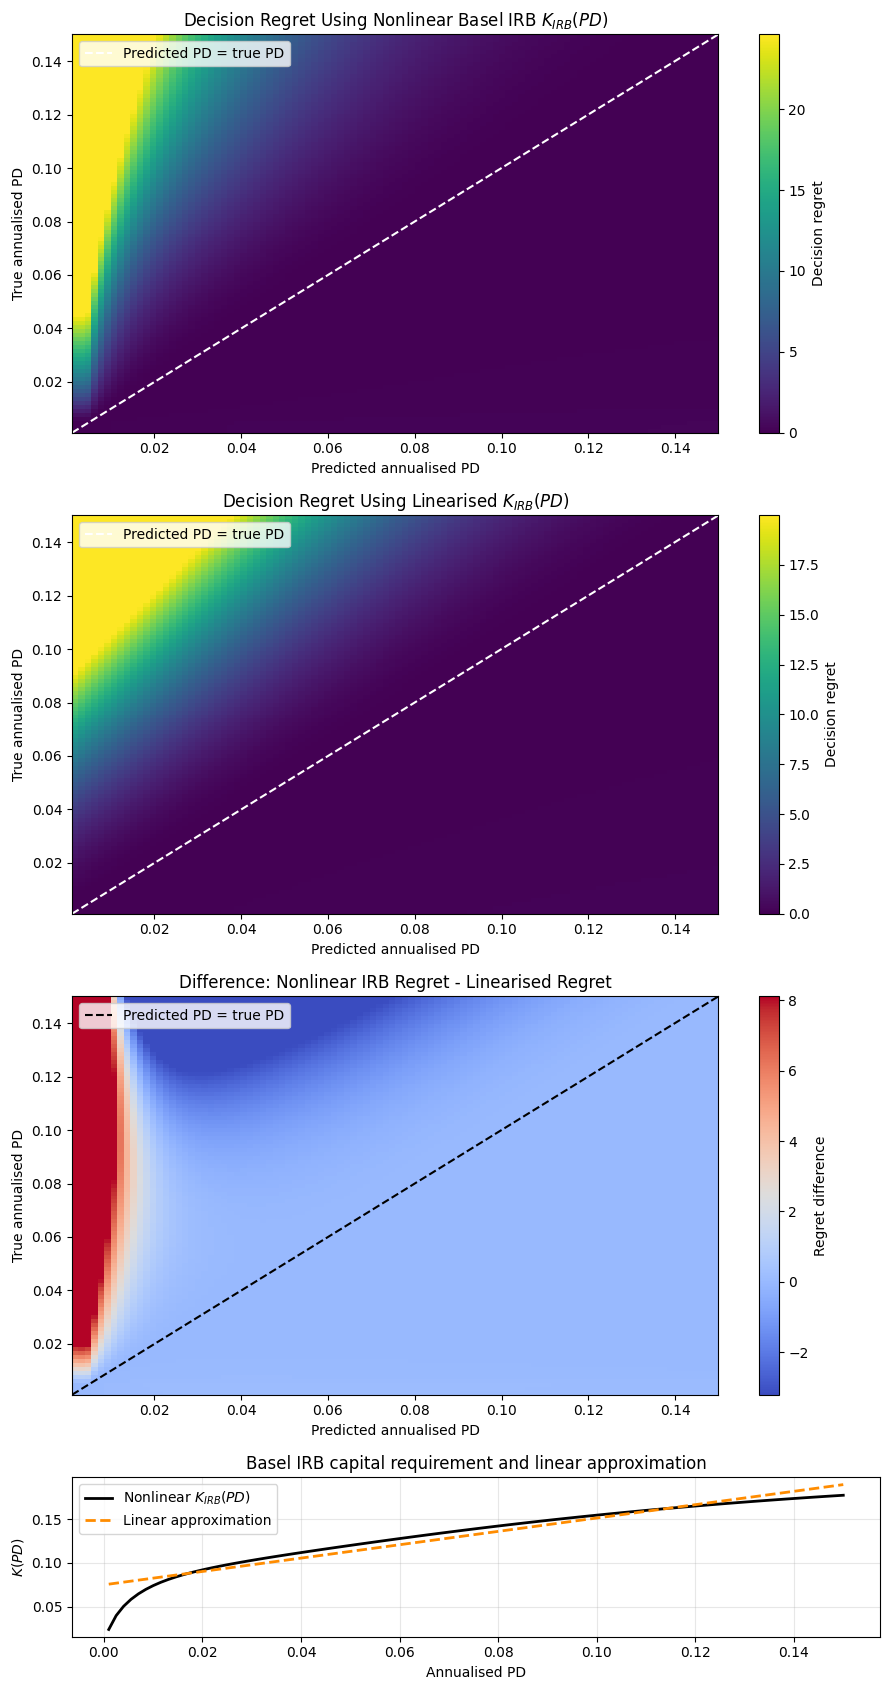

In [10]:
# %% Decision regret from PD forecast errors through nonlinear Basel IRB capital

PD_EPS = 1e-6
PD_MAX = 0.99


LGD    = 0.45
Y_BAR  = 0.05
LAMBDA = 50
K1 = 1
ELL = 10

def _clip_pd(pd):
    return float(np.clip(pd, PD_EPS, PD_MAX))


def u_given_alpha(alpha, c_true):
    """Realised utility for a chosen allocation under true charge-offs."""
    alpha = float(np.clip(alpha, 0.0, 1.0))
    pd_q = np.clip(c_true / LGD, PD_EPS, PD_MAX)
    pd_a = _clip_pd(1.0 - (1.0 - pd_q) ** 4)
    k = kirb(pd_a)

    exposure = ELL * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_true)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k * exposure
    shortfall = max(required_capital - available_buffer, 0.0)

    return terminal_capital - LAMBDA * shortfall**2


def alpha_from_predicted_pd(pd_pred):
    """Optimal allocation chosen using only the predicted annualised PD."""
    pd_pred = _clip_pd(pd_pred)
    k_pred = kirb(pd_pred)
    pd_q_pred = 1.0 - (1.0 - pd_pred) ** (1.0 / 4.0)
    c_pred = LGD * pd_q_pred

    def predicted_utility(alpha):
        exposure = ELL * alpha * K1
        terminal_capital_pred = K1 + exposure * (Y_BAR - c_pred)
        committed_capital = alpha * K1
        available_buffer_pred = terminal_capital_pred - committed_capital
        required_capital_pred = k_pred * exposure
        shortfall_pred = max(required_capital_pred - available_buffer_pred, 0.0)

        return terminal_capital_pred - LAMBDA * shortfall_pred

    result = minimize_scalar(
        lambda a: -predicted_utility(a),
        bounds=(0.0, 1.0),
        method="bounded",
    )
    return float(result.x)


def u_given_alpha_with_capital_fn(alpha, c_true, capital_fn):
    """Realised utility using a supplied capital requirement function."""
    alpha = float(np.clip(alpha, 0.0, 1.0))
    pd_q = np.clip(c_true / LGD, PD_EPS, PD_MAX)
    pd_a = _clip_pd(1.0 - (1.0 - pd_q) ** 4)
    k = capital_fn(pd_a)

    exposure = ELL * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_true)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k * exposure
    shortfall = max(required_capital - available_buffer, 0.0)

    return terminal_capital - LAMBDA * shortfall**2


def alpha_from_predicted_pd_with_capital_fn(pd_pred, capital_fn):
    """Optimal allocation from predicted PD using a supplied capital function."""
    pd_pred = _clip_pd(pd_pred)
    k_pred = capital_fn(pd_pred)
    pd_q_pred = 1.0 - (1.0 - pd_pred) ** (1.0 / 4.0)
    c_pred = LGD * pd_q_pred

    def predicted_utility(alpha):
        exposure = ELL * alpha * K1
        terminal_capital_pred = K1 + exposure * (Y_BAR - c_pred)
        committed_capital = alpha * K1
        available_buffer_pred = terminal_capital_pred - committed_capital
        required_capital_pred = k_pred * exposure
        shortfall_pred = max(required_capital_pred - available_buffer_pred, 0.0)

        return terminal_capital_pred - LAMBDA * shortfall_pred

    result = minimize_scalar(
        lambda a: -predicted_utility(a),
        bounds=(0.0, 1.0),
        method="bounded",
    )
    return float(result.x)


def oracle_alpha_with_capital_fn(c, capital_fn):
    """Oracle allocation under the same objective with a supplied capital function."""
    def realised_utility(alpha):
        return u_given_alpha_with_capital_fn(alpha, c, capital_fn)

    result = minimize_scalar(
        lambda a: -realised_utility(a),
        bounds=(0.0, 1.0),
        method="bounded",
    )
    return float(result.x)


# Use the observed charge-off range when available; otherwise fall back to a broad PD range.

pd_grid = np.linspace(0.001, 0.15, 100)

true_pd_grid = np.clip(pd_grid, PD_EPS, PD_MAX)
pred_pd_grid = np.clip(pd_grid, PD_EPS, PD_MAX)

true_pd_q_grid = 1.0 - (1.0 - true_pd_grid) ** (1.0 / 4.0)
true_c_grid = LGD * true_pd_q_grid
k_irb_grid = np.array([kirb(pd) for pd in pd_grid])
k_linear_coeffs = np.polyfit(pd_grid, k_irb_grid, 1)


def kirb_linear(pd):
    return float(np.polyval(k_linear_coeffs, _clip_pd(pd)))

# Precompute one-dimensional decisions before evaluating the full regret surface.
oracle_alphas = np.empty_like(true_pd_grid)
oracle_utilities = np.empty_like(true_pd_grid)
for i, c_true in enumerate(true_c_grid):
    alpha_result = oracle_alpha(c_true)
    alpha_oracle = alpha_result[0] if isinstance(alpha_result, tuple) else alpha_result
    oracle_alphas[i] = alpha_oracle
    oracle_utilities[i] = u_given_alpha(alpha_oracle, c_true)

predicted_alphas = np.array([alpha_from_predicted_pd(pd_pred) for pd_pred in pred_pd_grid])

regret_grid = np.empty((len(true_pd_grid), len(pred_pd_grid)))
for i, c_true in enumerate(true_c_grid):
    for j, alpha_pred in enumerate(predicted_alphas):
        realised_predicted_utility = u_given_alpha(alpha_pred, c_true)
        regret_grid[i, j] = oracle_utilities[i] - realised_predicted_utility

regret_grid_irb = regret_grid.copy()

# Recompute the same decision problem under a linearised capital rule.
oracle_alphas_linear = np.empty_like(true_pd_grid)
oracle_utilities_linear = np.empty_like(true_pd_grid)
for i, c_true in enumerate(true_c_grid):
    alpha_oracle_linear = oracle_alpha_with_capital_fn(c_true, kirb_linear)
    oracle_alphas_linear[i] = alpha_oracle_linear
    oracle_utilities_linear[i] = u_given_alpha_with_capital_fn(alpha_oracle_linear, c_true, kirb_linear)

predicted_alphas_linear = np.array([
    alpha_from_predicted_pd_with_capital_fn(pd_pred, kirb_linear)
    for pd_pred in pred_pd_grid
])

regret_grid_linear = np.empty((len(true_pd_grid), len(pred_pd_grid)))
for i, c_true in enumerate(true_c_grid):
    for j, alpha_pred_linear in enumerate(predicted_alphas_linear):
        realised_predicted_utility_linear = u_given_alpha_with_capital_fn(alpha_pred_linear, c_true, kirb_linear)
        regret_grid_linear[i, j] = oracle_utilities_linear[i] - realised_predicted_utility_linear

regret_grid_difference = regret_grid_irb - regret_grid_linear

diag_regret_irb = np.diag(regret_grid_irb)
print("IRB regret min/max:", np.nanmin(regret_grid_irb), np.nanmax(regret_grid_irb))
print("IRB regret 95th percentile:", np.nanpercentile(regret_grid_irb, 95))
print("IRB max diagonal regret:", np.nanmax(diag_regret_irb))
print("IRB predicted alpha range:", np.nanmin(predicted_alphas), np.nanmax(predicted_alphas))
print("IRB oracle alpha range:", np.nanmin(oracle_alphas), np.nanmax(oracle_alphas))
print("Linear regret min/max:", np.nanmin(regret_grid_linear), np.nanmax(regret_grid_linear))
print("Linear regret 95th percentile:", np.nanpercentile(regret_grid_linear, 95))
print("Linear predicted alpha range:", np.nanmin(predicted_alphas_linear), np.nanmax(predicted_alphas_linear))
print("Linear oracle alpha range:", np.nanmin(oracle_alphas_linear), np.nanmax(oracle_alphas_linear))

fig, axes = plt.subplots(4, 1, figsize=(9, 17), gridspec_kw={"height_ratios": [3, 3, 3, 1.2]})
extent = [pred_pd_grid[0], pred_pd_grid[-1], true_pd_grid[0], true_pd_grid[-1]]

vmax_irb = np.nanpercentile(regret_grid_irb, 95)
heatmap_irb = axes[0].imshow(
    regret_grid_irb,
    origin="lower",
    aspect="auto",
    extent=extent,
    cmap="viridis",
    vmin=0,
    vmax=vmax_irb,
)
axes[0].plot(pd_grid, pd_grid, color="white", linewidth=1.5, linestyle="--", label="Predicted PD = true PD")
axes[0].set_title(r"Decision Regret Using Nonlinear Basel IRB $K_{IRB}(PD)$")
axes[0].set_xlabel("Predicted annualised PD")
axes[0].set_ylabel("True annualised PD")
axes[0].legend(loc="upper left", frameon=True)
cbar = fig.colorbar(heatmap_irb, ax=axes[0])
cbar.set_label("Decision regret")

vmax_linear = np.nanpercentile(regret_grid_linear, 95)
heatmap_linear = axes[1].imshow(
    regret_grid_linear,
    origin="lower",
    aspect="auto",
    extent=extent,
    cmap="viridis",
    vmin=0,
    vmax=vmax_linear,
)
axes[1].plot(pd_grid, pd_grid, color="white", linewidth=1.5, linestyle="--", label="Predicted PD = true PD")
axes[1].set_title(r"Decision Regret Using Linearised $K_{IRB}(PD)$")
axes[1].set_xlabel("Predicted annualised PD")
axes[1].set_ylabel("True annualised PD")
axes[1].legend(loc="upper left", frameon=True)
cbar = fig.colorbar(heatmap_linear, ax=axes[1])
cbar.set_label("Decision regret")

vmin_difference = np.nanpercentile(regret_grid_difference, 5)
vmax_difference = np.nanpercentile(regret_grid_difference, 95)
heatmap_difference = axes[2].imshow(
    regret_grid_difference,
    origin="lower",
    aspect="auto",
    extent=extent,
    cmap="coolwarm",
    vmin=vmin_difference,
    vmax=vmax_difference,
)
axes[2].plot(pd_grid, pd_grid, color="black", linewidth=1.5, linestyle="--", label="Predicted PD = true PD")
axes[2].set_title(r"Difference: Nonlinear IRB Regret - Linearised Regret")
axes[2].set_xlabel("Predicted annualised PD")
axes[2].set_ylabel("True annualised PD")
axes[2].legend(loc="upper left", frameon=True)
cbar = fig.colorbar(heatmap_difference, ax=axes[2])
cbar.set_label("Regret difference")

k_linear_grid = np.array([kirb_linear(pd) for pd in pd_grid])
axes[3].plot(pd_grid, k_irb_grid, color="black", linewidth=2, label=r"Nonlinear $K_{IRB}(PD)$")
axes[3].plot(pd_grid, k_linear_grid, color="darkorange", linewidth=2, linestyle="--", label="Linear approximation")
axes[3].set_title(r"Basel IRB capital requirement and linear approximation")
axes[3].set_xlabel("Annualised PD")
axes[3].set_ylabel(r"$K(PD)$")
axes[3].legend(loc="best")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Regret min/max: 0.0 105.14136709144472
Regret 95th percentile: 24.628231892811122
Max diagonal regret: 0.0012111916832582281
Predicted alpha range: 0.4079214608238519 0.9999940391390134
Oracle alpha range: 0.40845800238633734 0.9999940391390134


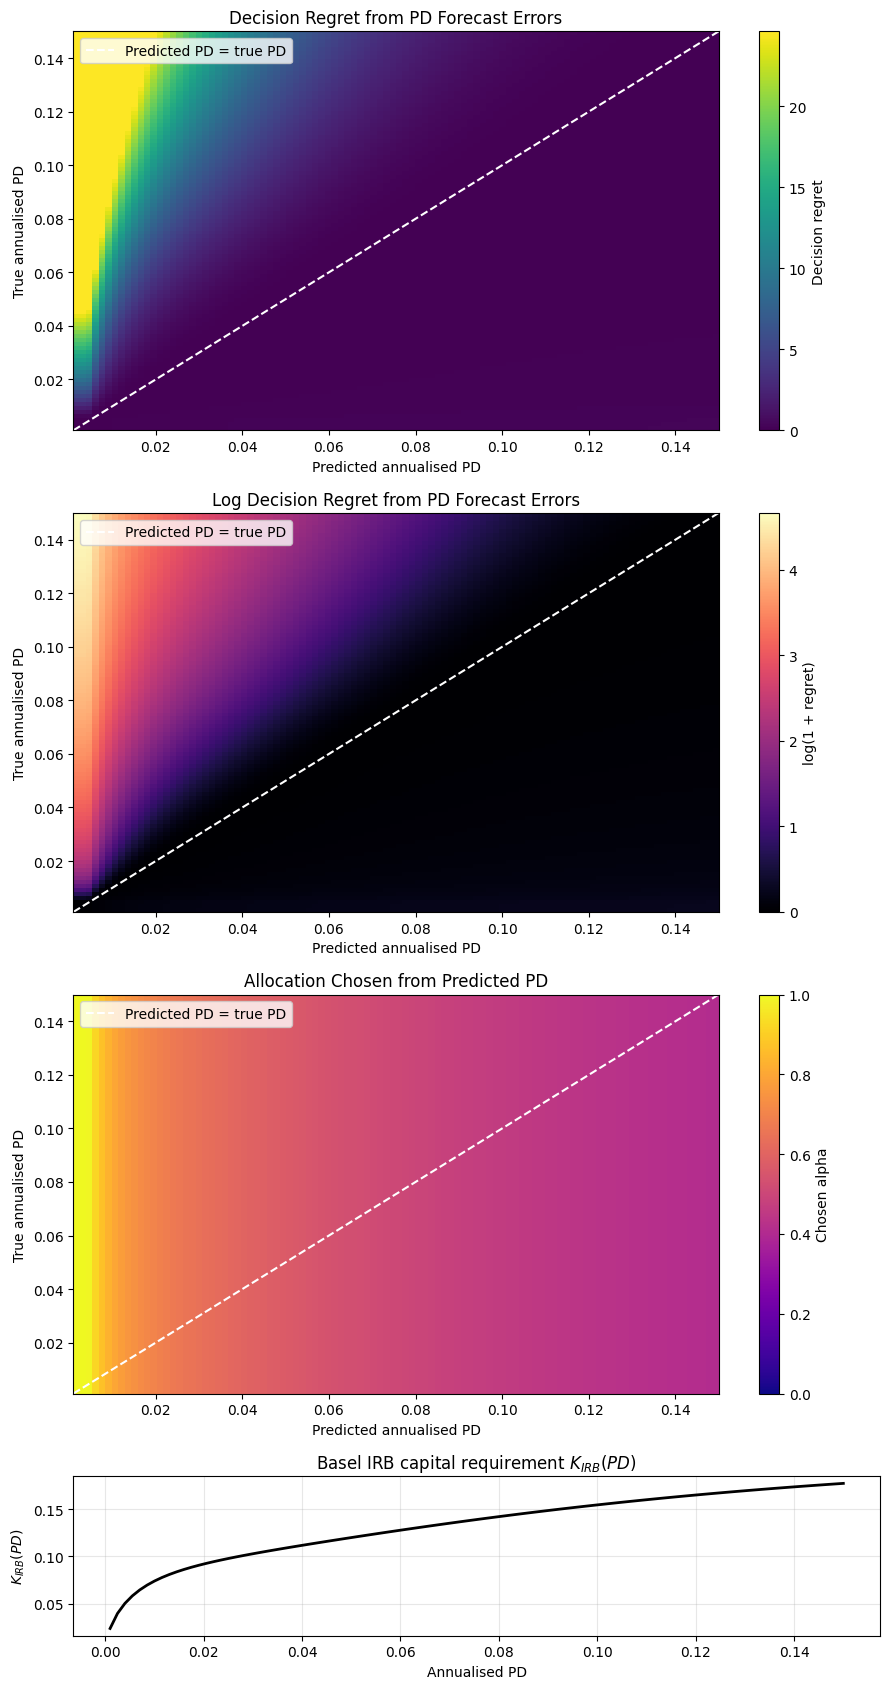

In [11]:
# %% Overall nonlinear regret diagnostics

# Recreate the original overall regret plots using the nonlinear Basel IRB surface.
overall_regret_grid = regret_grid_irb if "regret_grid_irb" in globals() else regret_grid
overall_predicted_alphas = predicted_alphas
overall_oracle_alphas = oracle_alphas

diag_regret = np.diag(overall_regret_grid)
print("Regret min/max:", np.nanmin(overall_regret_grid), np.nanmax(overall_regret_grid))
print("Regret 95th percentile:", np.nanpercentile(overall_regret_grid, 95))
print("Max diagonal regret:", np.nanmax(diag_regret))
print("Predicted alpha range:", np.nanmin(overall_predicted_alphas), np.nanmax(overall_predicted_alphas))
print("Oracle alpha range:", np.nanmin(overall_oracle_alphas), np.nanmax(overall_oracle_alphas))

vmax = np.nanpercentile(overall_regret_grid, 95)
alpha_grid = np.tile(overall_predicted_alphas, (len(true_pd_grid), 1))
log_regret_grid = np.log1p(overall_regret_grid)
extent = [pred_pd_grid[0], pred_pd_grid[-1], true_pd_grid[0], true_pd_grid[-1]]

fig, axes = plt.subplots(4, 1, figsize=(9, 17), gridspec_kw={"height_ratios": [3, 3, 3, 1.2]})

heatmap = axes[0].imshow(
    overall_regret_grid,
    origin="lower",
    aspect="auto",
    extent=extent,
    cmap="viridis",
    vmin=0,
    vmax=vmax,
)
axes[0].plot(pd_grid, pd_grid, color="white", linewidth=1.5, linestyle="--", label="Predicted PD = true PD")
axes[0].set_title("Decision Regret from PD Forecast Errors")
axes[0].set_xlabel("Predicted annualised PD")
axes[0].set_ylabel("True annualised PD")
axes[0].legend(loc="upper left", frameon=True)
cbar = fig.colorbar(heatmap, ax=axes[0])
cbar.set_label("Decision regret")

log_heatmap = axes[1].imshow(
    log_regret_grid,
    origin="lower",
    aspect="auto",
    extent=extent,
    cmap="magma",
)
axes[1].plot(pd_grid, pd_grid, color="white", linewidth=1.5, linestyle="--", label="Predicted PD = true PD")
axes[1].set_title("Log Decision Regret from PD Forecast Errors")
axes[1].set_xlabel("Predicted annualised PD")
axes[1].set_ylabel("True annualised PD")
axes[1].legend(loc="upper left", frameon=True)
cbar = fig.colorbar(log_heatmap, ax=axes[1])
cbar.set_label("log(1 + regret)")

alpha_heatmap = axes[2].imshow(
    alpha_grid,
    origin="lower",
    aspect="auto",
    extent=extent,
    cmap="plasma",
    vmin=0,
    vmax=1,
)
axes[2].plot(pd_grid, pd_grid, color="white", linewidth=1.5, linestyle="--", label="Predicted PD = true PD")
axes[2].set_title("Allocation Chosen from Predicted PD")
axes[2].set_xlabel("Predicted annualised PD")
axes[2].set_ylabel("True annualised PD")
axes[2].legend(loc="upper left", frameon=True)
cbar = fig.colorbar(alpha_heatmap, ax=axes[2])
cbar.set_label("Chosen alpha")

k_irb_grid_overall = np.array([kirb(pd) for pd in pd_grid])
axes[3].plot(pd_grid, k_irb_grid_overall, color="black", linewidth=2)
axes[3].set_title(r"Basel IRB capital requirement $K_{IRB}(PD)$")
axes[3].set_xlabel("Annualised PD")
axes[3].set_ylabel(r"$K_{IRB}(PD)$")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
